<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#Данные" data-toc-modified-id="Данные-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><b>Данные</b></a></span></li><li><span><a href="#Задание" data-toc-modified-id="Задание-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><b>Задание</b></a></span></li></ul></div>

---

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

---

В этом ноутбуке Вам предстоит самостоятельно попрактиковаться в написаноо нейросетей для распознавания датасета, похожего на MNIST, но более интересного -- чёрно-белых изображений одежды.

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

<img src="https://emiliendupont.github.io/imgs/mnist-chicken/mnist-and-fashion-examples.png">

<h2 style="text-align: center;"><b>Данные</b></h2>

## Что делаем

Классификация **FashionMNIST** (10 классов одежды, 28×28, ч/б). Цель из условия — >95% accuracy на тесте.

**Архитектура:** свёрточная сеть в духе VGG — 3 блока `[Conv-BN-ReLU] × 2 -> MaxPool -> Dropout` (всего **6 свёрточных слоёв**) + полносвязная голова на 2 слоя.

**Оглавление:** загрузка датасета · просмотр классов · обучение CNN (20 эпох, Adam) · кривые обучения · accuracy по классам.

Мы будем работать с картинками одежды (чёрно-белыми, то есть цветовых каналов не 3, а 1). По входной картинке нужно предсказать тип одежды.

In [1]:
# !pip install torchvision

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [2]:
basic_transform = transforms.ToTensor()

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                             download=True, transform=basic_transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=basic_transform)

trainloader = DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')


Каждая картинка имеет класс от 0 до 9, расшифровка меток класса:  

|class_id|class_name|
|----|----|
|0| T-shirt/top|
|1| Trouser|
|2| Pullover|
|3| Dress|
|4| Coat|
|5| Sandal|
|6| Shirt|
|7| Sneaker|
|8| Bag|
|9| Ankle boot| 

Посмотрите на датасет.
* Сколько в нём классов?
* Сколько картинок в train? В test?
* Выведите несколько картинок с помощью `pyplot`

In [3]:
print(f'train: {len(trainset)}')
print(f'test:  {len(testset)}')
print(f'классов: {len(classes)}')
print(f'shape: {trainset[0][0].shape}')

labels_np = np.array(trainset.targets)
unique, counts = np.unique(labels_np, return_counts=True)
print()
for cls_id, cnt in zip(unique, counts):
    print(f'  {cls_id} {classes[cls_id]:<12}: {cnt}')


train: 60000
test:  10000
классов: 10
shape: torch.Size([1, 28, 28])

  0 T-shirt/top : 6000
  1 Trouser     : 6000
  2 Pullover    : 6000
  3 Dress       : 6000
  4 Coat        : 6000
  5 Sandal      : 6000
  6 Shirt       : 6000
  7 Sneaker     : 6000
  8 Bag         : 6000
  9 Ankle boot  : 6000


/tmp/ipykernel_13370/160123537.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels_np = np.array(trainset.targets)


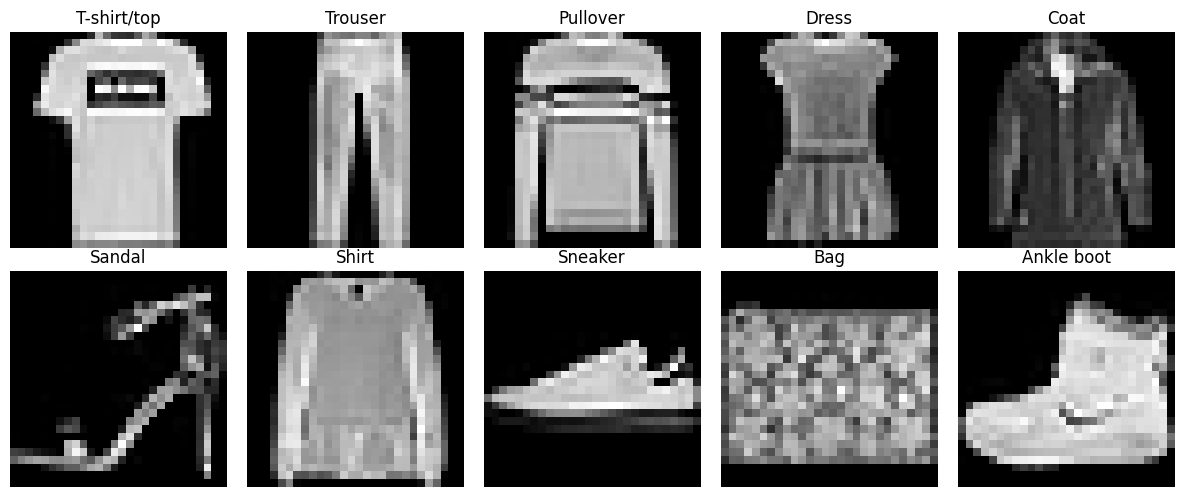

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_id, ax in enumerate(axes.ravel()):
    idx = np.where(labels_np == cls_id)[0][0]
    img, _ = trainset[idx]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(classes[cls_id])
    ax.axis('off')
plt.tight_layout()
plt.show()


<h2 style="text-align: center;"><b>Задание</b></h2>

Используя материалы семинаров по многослойным  и свёрточным сетям, напишите Свёрточную сеть, классифицирующую этот датасет.
Если качество, которое получается у  нейросети, выше 95%, то Вы решили задачу с точностью, которую можно использовать в жизни.

In [5]:
mean, std = (0.2860,), (0.3530,)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                             download=True, transform=train_transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=test_transform)

BATCH_SIZE = 128
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)


In [6]:
# 3 свёрточных блока: 1->32->64->128 каналов, размер 28->14->7->3 после трёх MaxPool.
# Внутри блока — 2 свёртки 3×3 с padding=1 (rec.field как у 5×5, но меньше параметров).
# Итого: 6 Conv + 2 Linear. BatchNorm везде, Dropout 0.25 после блоков и 0.5 на FC.
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


net = ConvNet().to(device)
n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'параметров: {n_params:,}')


параметров: 585,578


Обучение: 20 эпох, Adam (`lr=1e-3`, `weight_decay=1e-4`), `CrossEntropyLoss`, cosine-annealing для lr. Лучшие веса по test accuracy сохраняем в `best_convnet.pt`.

In [7]:
NUM_EPOCHS = 20
LR = 1e-3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss_sum += loss_fn(logits, y).item() * X.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += X.size(0)
    return loss_sum / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    net.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for X, y in trainloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = net(X)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        running_total += X.size(0)

    scheduler.step()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    test_loss, test_acc = evaluate(net, testloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(net.state_dict(), 'best_convnet.pt')

    print(f'epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
          f'test loss {test_loss:.4f} acc {test_acc:.4f}')

print(f'best test acc: {best_acc:.4f}')


/home/pavel/projects/DeepLerningLabs/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['test_loss'], label='test')
axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['test_acc'], label='test')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
net.load_state_dict(torch.load('best_convnet.pt', map_location=device))
net.eval()

class_correct = [0] * len(classes)
class_total = [0] * len(classes)
all_correct, all_total = 0, 0

with torch.no_grad():
    for X, y in testloader:
        X, y = X.to(device), y.to(device)
        preds = net(X).argmax(dim=1)
        correct_mask = (preds == y)
        all_correct += correct_mask.sum().item()
        all_total += y.size(0)
        for cls_id in range(len(classes)):
            mask = (y == cls_id)
            class_total[cls_id] += mask.sum().item()
            class_correct[cls_id] += (correct_mask & mask).sum().item()

print(f'test acc: {all_correct / all_total:.4f}')
print()
for cls_id, name in enumerate(classes):
    acc = class_correct[cls_id] / class_total[cls_id] if class_total[cls_id] else 0.0
    print(f'  {name:<12}: {acc:.4f}')
